# Test of Algorithm for parameter computation
1. Checked for various kinds of simulations  
2. Plot for simulation with more than 2 transitions

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib widget

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import matplotlib.pyplot as plt

#### Create objects to read data and perform computations

In [2]:
reader = DataRead()
analyse = AnalysisFunc()

#### Load data    

In [3]:
df_check = reader.data_read_csv("fn_itr_200.csv")

#### Calling smooth(df) and trans_state_time(df,dt) function
Returns the dictionary with parameters and crossings

In [4]:
l = analyse.trans_state_time(analyse.smooth(df_check[145]), 0.05)

Print upper crossing

In [5]:
l["up_cros"]

[391.55, 951.1500000000001, 1693.3500000000001, 1876.3500000000001]

Print lower crossing

In [6]:
l["low_cros"]

[356.6,
 523.7,
 921.5500000000001,
 1174.25,
 1638.6000000000001,
 1813.95,
 1844.45]

Print transition times

In [7]:
l["trans_time"]

[34.95, 29.6, 54.75, 31.900000000000002]

Print average time spent in sync state

In [8]:
l["state_time"]

198.38333333333335

#### Plot of global order with all crossings marked

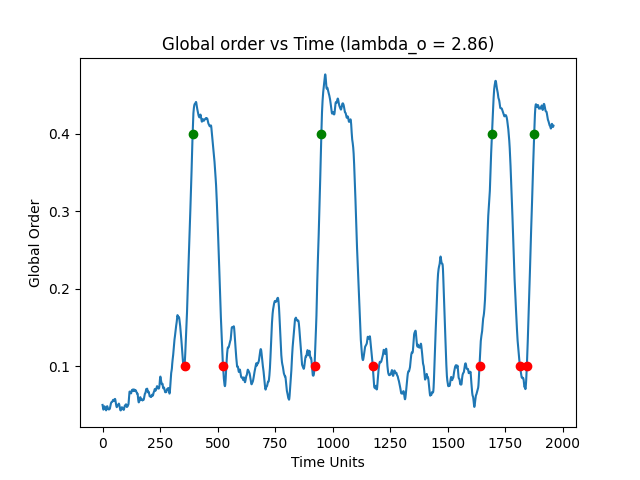

In [9]:
time = analyse.get_time(df_check[2], 0.05)
plt.figure()
plt.plot(time, analyse.smooth(df_check[145]))
plt.plot(l["low_cros"], [0.1] * len(l["low_cros"]), "ro")
plt.plot(l["up_cros"], [0.4] * len(l["up_cros"]), "go")
plt.xlabel("Time Units")
plt.ylabel("Global Order")
plt.title("Global order vs Time (lambda_o = 2.86)")
plt.show()